<a href="https://colab.research.google.com/github/PanconquesoHH/Laboratorios-ia/blob/main/L4D2_Regresion_Logistica_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción del nivel de actividad de un jugador de Left 4 Dead 2 mediante Regresión Logística

**Dataset:** estadísticas de jugadores de *Left 4 Dead 2* (L4D2), obtenidas mediante *scraping* de fuentes públicas, con identificadores anonimizados. Contiene, para cada jugador, la cantidad de disparos, bajas (*kills*) y porcentaje de uso de cada una de las armas del juego, además de estadísticas de fuego amigo y la dificultad habitual de juego.

**Objetivo del cuadernillo:** predecir qué tan activo es un jugador (en función de sus horas jugadas) a partir de su estilo de juego (armas utilizadas, precisión, fuego amigo, dificultad, etc.).

Dado que se exige explícitamente el uso de **regresión logística (clasificación)** para la determinación de los parámetros $\theta$, la variable *Horas jugadas* (`Playtime_(Hours)`), que originalmente es continua, se transforma en una variable **binaria**:

- **Clase 1 – Jugador frecuente:** horas jugadas por encima de la mediana del dataset.
- **Clase 0 – Jugador ocasional:** horas jugadas iguales o por debajo de la mediana.

De esta manera se conserva la idea original (estimar cuánto juega una persona) pero formulada como un problema de clasificación binaria, tal como lo requiere la consigna del trabajo.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Manejo de datos tabulares
import pandas as pd

# Cálculo numérico y vectorial
import numpy as np

# Graficas
from matplotlib import pyplot as plt

# Módulo de optimización de scipy (segundo método para hallar theta)
from scipy import optimize

# División de datos en entrenamiento / prueba
from sklearn.model_selection import train_test_split

# Métricas de evaluación
from sklearn.metrics import confusion_matrix

%matplotlib inline

## 1. Carga del dataset

Se carga el archivo `l4d2_player_stats_final.csv` utilizando **Pandas**, lo que permite trabajar con los datos como una tabla (`DataFrame`), inspeccionar sus columnas, tipos de datos y estadísticas descriptivas antes de construir el modelo.

In [3]:
ruta = '/content/drive/MyDrive/lab4/l4d2_player_stats_final.csv'
df = pd.read_csv(ruta)

print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (20830, 113)


,Username,Playtime_(Hours),Pistol_Shots,Pistol_Kills,Pistol_Usage,Magnum_Shots,Magnum_Kills,Magnum_Usage,Uzi_Shots,Uzi_Kills,...,Knife_Usage,Molotovs_Thrown,Molotov_Kills,Pipe_Bombs_Thrown,Pipe_Bomb_Kills,Bile_Jars_Thrown,Bile_Jar_Hits,Most_Friendly_Fire,Difficulty,Average_Friendly_Fire
0,0,2433.577222,94665.0,10470.0,2.77,121222.0,27056.0,7.16,44666.0,5165.0,...,0.47,11166.0,99278.0,5817.0,23433.0,5802.0,12863.0,13653.0,Normal,142.0
1,1,121.879444,9136.0,1371.0,1.47,14928.0,6802.0,7.30,997.0,187.0,...,0.03,788.0,10141.0,977.0,6962.0,519.0,1557.0,1914.0,Expert,89.0
2,2,69.955278,4100.0,693.0,4.87,222.0,133.0,0.93,2834.0,271.0,...,0.00,23.0,130.0,445.0,1202.0,44.0,83.0,3195.0,Expert,58.0
3,3,48.421667,7369.0,1208.0,5.99,784.0,250.0,1.24,3322.0,496.0,...,0.00,135.0,1090.0,105.0,716.0,48.0,75.0,1412.0,Expert,76.0
4,4,307.639722,51944.0,9481.0,8.93,20545.0,6813.0,6.42,38224.0,5493.0,...,0.00,613.0,4797.0,515.0,4195.0,272.0,424.0,10851.0,Expert,112.0


In [4]:
# Información general: tipos de dato y valores nulos por columna
df.info()
print('\nValores nulos totales:', df.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20830 entries, 0 to 20829
Columns: 113 entries, Username to Average_Friendly_Fire
dtypes: float64(111), int64(1), object(1)
memory usage: 18.0+ MB

Valores nulos totales: 0


In [5]:
# Estadísticas descriptivas de la variable objetivo original
df['Playtime_(Hours)'].describe()

,Playtime_(Hours)
count,20830.000000
mean,104.684003
std,1974.873029
min,0.000000
25%,19.027153
50%,36.110417
75%,73.698333
max,277827.960278


## 2. Preprocesamiento con Pandas

El dataset original tiene **113 columnas**: un identificador de usuario, las horas jugadas, y por cada una de las ~36 armas del juego sus disparos, bajas y porcentaje de uso, además de estadísticas de fuego amigo y la dificultad de juego.

Usar las 113 columnas crudas como entrada de un modelo de regresión logística resulta poco práctico (alta dimensionalidad, columnas redundantes entre sí) y dificulta la interpretación de los resultados. Por ello, con Pandas se construyen **variables agregadas** que resumen el estilo de juego de cada usuario:

| Variable creada | Descripción |
|---|---|
| `Total_Shots` | Suma de todos los disparos realizados con cualquier arma |
| `Total_Kills` | Suma de todas las bajas realizadas con cualquier arma |
| `Overall_Accuracy` | Precisión global = `Total_Kills / Total_Shots` |
| `Ranged_Kills` | Bajas con armas de fuego (pistolas, rifles, escopetas, etc.) |
| `Melee_Kills` | Bajas con armas cuerpo a cuerpo (machete, hacha, katana, etc.) |
| `Explosive_Kills` | Bajas/impactos con molotov, bomba de tubo y frasco de bilis |
| `Weapon_Diversity` | Cantidad de armas distintas que el jugador ha usado al menos una vez |
| `Difficulty_Ordinal` | Dificultad habitual codificada como valor ordinal (Easy=0 … Expert=3) |

A estas se suman `Most_Friendly_Fire` y `Average_Friendly_Fire`, que ya vienen calculadas en el dataset original.

Finalmente, se elimina la columna `Username` (es solo un identificador, no aporta información predictiva) y se construye la variable objetivo binaria `Playtime_Class` a partir de `Playtime_(Hours)`.

In [6]:
# Listas de armas según su tipo, usadas para agregar columnas
armas_fuego = ['Pistol','Magnum','Uzi','Silenced_SMG','MP5','Pump_Shotgun','Chrome_Shotgun',
               'Tactical_Shotgun','Combat_Shotgun','Assault_Rifle','Desert_Rifle','AK-47','SG-552',
               'Hunting_Rifle','Military_Sniper_Rifle','AWP','Scout','Grenade_Launcher','M60','Minigun']

armas_cuerpo_a_cuerpo = ['Baseball_Bat','Chainsaw','Cricket_Bat','Crowbar','Electric_Guitar','Fire_Axe',
                         'Frying_Pan','Katana','Machete','Tonfa','Golf_Club','Pitchfork','Shovel','Knife']

# Columnas de disparos, bajas y uso (todas las armas)
columnas_disparos = [c for c in df.columns if c.endswith('_Shots')]
columnas_bajas = [c for c in df.columns if c.endswith('_Kills')]
columnas_uso = [c for c in df.columns if c.endswith('_Usage')]

print('Columnas de disparos:', len(columnas_disparos))
print('Columnas de bajas:', len(columnas_bajas))
print('Columnas de uso:', len(columnas_uso))

Columnas de disparos: 34
Columnas de bajas: 36
Columnas de uso: 34


In [7]:
# Se construyen las variables agregadas en un DataFrame separado y luego se concatenan
nuevas_columnas = pd.DataFrame(index=df.index)

nuevas_columnas['Total_Shots'] = df[columnas_disparos].sum(axis=1)
nuevas_columnas['Total_Kills'] = df[columnas_bajas].sum(axis=1)
nuevas_columnas['Overall_Accuracy'] = np.where(nuevas_columnas['Total_Shots'] > 0,
                                                nuevas_columnas['Total_Kills'] / nuevas_columnas['Total_Shots'],
                                                0)
nuevas_columnas['Ranged_Kills'] = df[[f'{arma}_Kills' for arma in armas_fuego]].sum(axis=1)
nuevas_columnas['Melee_Kills'] = df[[f'{arma}_Kills' for arma in armas_cuerpo_a_cuerpo]].sum(axis=1)
nuevas_columnas['Explosive_Kills'] = df['Molotov_Kills'] + df['Pipe_Bomb_Kills'] + df['Bile_Jar_Hits']
nuevas_columnas['Weapon_Diversity'] = (df[columnas_uso] > 0).sum(axis=1)

mapa_dificultad = {'Easy': 0, 'Normal': 1, 'Advanced': 2, 'Expert': 3}
nuevas_columnas['Difficulty_Ordinal'] = df['Difficulty'].map(mapa_dificultad)

df = pd.concat([df, nuevas_columnas], axis=1)
df[list(nuevas_columnas.columns)].head()

,Total_Shots,Total_Kills,Overall_Accuracy,Ranged_Kills,Melee_Kills,Explosive_Kills,Weapon_Diversity,Difficulty_Ordinal
0,1307406.0,500607.0,0.382901,270071.0,107825.0,135574.0,34,1
1,159790.0,110252.0,0.689981,76311.0,16838.0,18660.0,31,3
2,49129.0,15569.0,0.316900,10728.0,3509.0,1415.0,27,3
3,57967.0,21960.0,0.378836,17236.0,2918.0,1881.0,27,3
4,396324.0,115171.0,0.290598,93117.0,13062.0,9416.0,29,3


In [8]:
# Variable objetivo: se binariza Playtime_(Hours) usando la mediana como umbral
mediana_horas = df['Playtime_(Hours)'].median()
df['Playtime_Class'] = (df['Playtime_(Hours)'] > mediana_horas).astype(int)

print('Mediana de horas jugadas:', round(mediana_horas, 2))
print('\nDistribución de clases (0 = Ocasional, 1 = Frecuente):')
print(df['Playtime_Class'].value_counts())

Mediana de horas jugadas: 36.11

Distribución de clases (0 = Ocasional, 1 = Frecuente):
Playtime_Class
1    10415
0    10415
Name: count, dtype: int64


Se observa que el umbral de la mediana genera dos clases perfectamente balanceadas (50% / 50%), lo cual es deseable para entrenar y evaluar un modelo de clasificación sin que el desbalance de clases distorsione la métrica de precisión (*accuracy*).

In [9]:
# Selección final de variables predictoras (X) y variable objetivo (y)
variables_predictoras = ['Total_Shots', 'Total_Kills', 'Overall_Accuracy', 'Melee_Kills',
                          'Ranged_Kills', 'Explosive_Kills', 'Weapon_Diversity',
                          'Most_Friendly_Fire', 'Average_Friendly_Fire', 'Difficulty_Ordinal']

X = df[variables_predictoras].values.astype(float)
y = df['Playtime_Class'].values.astype(float)

print('X:', X.shape)
print('y:', y.shape)

X: (20830, 10)
y: (20830,)


## 3. División en conjunto de entrenamiento (80%) y prueba (20%)

Para poder validar el modelo de forma honesta, el 20% de los datos se aparta como conjunto de **prueba** y **no se utiliza en ningún momento durante el entrenamiento** (ni para ajustar $\theta$, ni para normalizar). El 80% restante se usa como conjunto de **entrenamiento**. La división se hace de forma **estratificada** respecto a `Playtime_Class` para mantener la proporción 50/50 en ambos conjuntos.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Tamaño entrenamiento:', X_train.shape[0], '(%.1f%%)' % (100*X_train.shape[0]/X.shape[0]))
print('Tamaño prueba:      ', X_test.shape[0], '(%.1f%%)' % (100*X_test.shape[0]/X.shape[0]))

Tamaño entrenamiento: 16664 (80.0%)
Tamaño prueba:       4166 (20.0%)


## 4. Normalización de características

Las variables predictoras tienen escalas muy distintas (por ejemplo, `Total_Shots` puede llegar a cientos de miles, mientras que `Overall_Accuracy` está entre 0 y 1). Esto perjudica la convergencia del descenso por el gradiente. Se aplica normalización estándar (media 0, desviación estándar 1):

$$x_j^{(i)} := \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

**Importante:** la media $\mu$ y desviación $\sigma$ se calculan **únicamente con el conjunto de entrenamiento**, y luego se aplican también al conjunto de prueba. De este modo, ninguna información del conjunto de prueba se filtra hacia el proceso de ajuste del modelo.

In [11]:
def normalizarCaracteristicas(X, mu=None, sigma=None):
    # Si no se entregan mu y sigma, se calculan a partir de X (debe ser el conjunto de entrenamiento)
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# mu y sigma se calculan SOLO con el conjunto de entrenamiento
X_train_norm, mu, sigma = normalizarCaracteristicas(X_train)

# El mismo mu y sigma se reutilizan para normalizar el conjunto de prueba
X_test_norm, _, _ = normalizarCaracteristicas(X_test, mu, sigma)

print('Media de entrenamiento (primeras 3):', mu[:3])
print('Desv. estándar de entrenamiento (primeras 3):', sigma[:3])

Media de entrenamiento (primeras 3): [1.04467708e+05 4.17280370e+04 3.42789849e-01]
Desv. estándar de entrenamiento (primeras 3): [6.93791843e+05 6.59836337e+05 1.10114147e-01]


In [12]:
# Se agrega la columna de unos (término de intercepción / theta_0) a ambos conjuntos
m_train = X_train_norm.shape[0]
m_test = X_test_norm.shape[0]

X_train_b = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

n = X_train_b.shape[1]  # número de parámetros theta (incluye theta_0)
print('Forma de X_train_b:', X_train_b.shape)
print('Forma de X_test_b: ', X_test_b.shape)

Forma de X_train_b: (16664, 11)
Forma de X_test_b:  (4166, 11)


## 5. Función sigmoidea

El modelo de regresión logística define la hipótesis como:

$$h_\theta(x) = g(\theta^T x)$$

donde $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Esta función comprime cualquier valor real al rango $(0, 1)$, lo que permite interpretar $h_\theta(x)$ como la probabilidad de que el jugador pertenezca a la clase 1 (jugador frecuente).

In [13]:
def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

# Verificación: g(0) debe ser 0.5
print('sigmoid(0) =', sigmoid(0))
print('sigmoid([-10, 0, 10]) =', sigmoid([-10, 0, 10]))

sigmoid(0) = 0.5
sigmoid([-10, 0, 10]) = [4.53978687e-05 5.00000000e-01 9.99954602e-01]


## 6. Función de costo y gradiente

La función de costo de la regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente respecto a cada parámetro $\theta_j$ es:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Se implementa una única función `costFunction` que retorna tanto el costo $J$ como el vector de gradientes, ya que ambos se usan tanto en el descenso por el gradiente manual como en `scipy.optimize`.

In [14]:
def costFunction(theta, X, y):
    m = y.size
    eps = 1e-10  # evita log(0) por estabilidad numérica
    h = sigmoid(X.dot(theta))

    J = (1 / m) * np.sum(-y * np.log(h + eps) - (1 - y) * np.log(1 - h + eps))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

# Costo inicial con theta = 0 (debe ser cercano a log(2) = 0.693, ya que las clases están balanceadas)
theta_inicial = np.zeros(n)
J_inicial, grad_inicial = costFunction(theta_inicial, X_train_b, y_train)
print('Costo con theta inicial (ceros):', J_inicial)

Costo con theta inicial (ceros): 0.6931471803599453


## 7. Caso 1 – Determinación de $\theta$ mediante descenso por el gradiente

Se implementa el algoritmo de descenso por el gradiente de forma manual, actualizando $\theta$ en cada iteración según:

$$\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}$$

Se guarda el valor de $J(\theta)$ en cada iteración para poder graficar la curva de convergencia del costo.

In [15]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(costFunction(theta, X, y)[0])

    return theta, J_history

In [16]:
alpha = 0.5
num_iters = 1000

theta_gd = np.zeros(n)
theta_gd, J_history_gd = descensoGradiente(theta_gd, X_train_b, y_train, alpha, num_iters)

print('Costo final (descenso por el gradiente):', J_history_gd[-1])
print('\ntheta obtenido:')
print(theta_gd)

Costo final (descenso por el gradiente): 0.35487799956712307

theta obtenido:
[ 1.12503052  5.01947022  1.83043405 -0.28739294  0.68849744  2.42101055
  6.21834748  1.32841685  1.414551   -0.89632426  0.25398803]


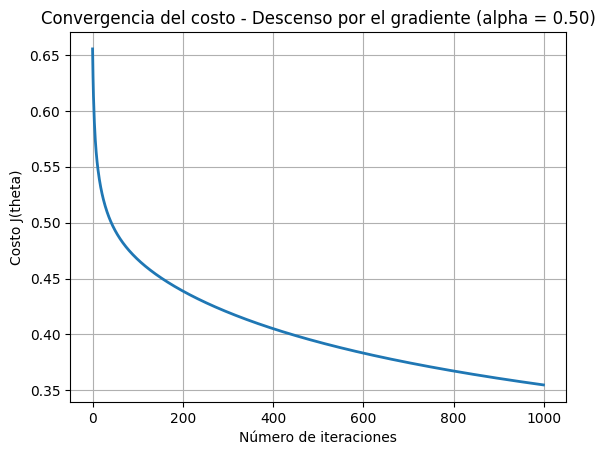

In [17]:
# Gráfico de costo - Caso 1: Descenso por el gradiente
plt.figure()
plt.plot(np.arange(len(J_history_gd)), J_history_gd, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J(theta)')
plt.title('Convergencia del costo - Descenso por el gradiente (alpha = %.2f)' % alpha)
plt.grid(True)
plt.show()

## 8. Caso 2 – Determinación de $\theta$ mediante `scipy.optimize`

Como alternativa al descenso por el gradiente manual, se utiliza el módulo [`scipy.optimize`](https://docs.scipy.org/doc/scipy/reference/optimize.html), que implementa algoritmos de optimización más eficientes (en este caso, el método de Newton truncado, `TNC`). Se aprovecha que `costFunction` ya retorna el gradiente (`jac=True`) para que el optimizador lo use directamente.

Mediante un `callback` se registra el valor de $J(\theta)$ en cada iteración del optimizador, con el fin de graficar también su curva de convergencia.

In [18]:
J_history_scipy = []

def registrar_costo(theta_actual):
    J, _ = costFunction(theta_actual, X_train_b, y_train)
    J_history_scipy.append(J)

theta_inicial = np.zeros(n)
opciones = {'maxfun': 400}

resultado = optimize.minimize(costFunction,
                               theta_inicial,
                               (X_train_b, y_train),
                               jac=True,
                               method='TNC',
                               callback=registrar_costo,
                               options=opciones)

theta_scipy = resultado.x
print('Costo final (scipy.optimize):', resultado.fun)
print('\ntheta obtenido:')
print(theta_scipy)

Costo final (scipy.optimize): 0.1786281331262643

theta obtenido:
[ 1.07892752e+01  1.01255151e+02  2.10159428e+01 -1.71593226e-01
  8.78200133e+00  2.90340483e+01 -2.91973162e-02  2.27812241e-01
  9.30126332e+00 -1.07900226e+01  4.48793772e-02]


/tmp/ipykernel_3392/311463435.py:3: RuntimeWarning: overflow encountered in exp
  g = 1 / (1 + np.exp(-z))


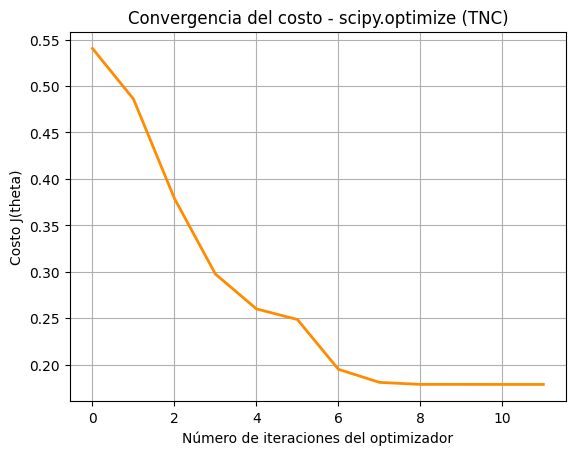

In [19]:
# Gráfico de costo - Caso 2: scipy.optimize
plt.figure()
plt.plot(np.arange(len(J_history_scipy)), J_history_scipy, lw=2, color='darkorange')
plt.xlabel('Número de iteraciones del optimizador')
plt.ylabel('Costo J(theta)')
plt.title('Convergencia del costo - scipy.optimize (TNC)')
plt.grid(True)
plt.show()

Se observa que `scipy.optimize` alcanza un costo menor en muchas menos iteraciones que el descenso por el gradiente manual, ya que utiliza información de segundo orden (aproximación del Hessiano) para dar pasos más eficientes hacia el mínimo.

## 9. Predicción y evaluación del modelo

Con el vector $\theta$ obtenido, la predicción de la clase para un ejemplo $x$ se define como:

$$
\hat{y} = \begin{cases} 1 & \text{si } h_\theta(x) \geq 0.5 \\ 0 & \text{si } h_\theta(x) < 0.5 \end{cases}
$$

Se evalúa cada uno de los dos conjuntos de parámetros ($\theta$ del descenso por el gradiente y $\theta$ de `scipy.optimize`) tanto en el conjunto de **entrenamiento** como en el conjunto de **prueba**, que no fue utilizado en ningún momento del ajuste.

In [20]:
def predict(theta, X):
    probabilidades = sigmoid(X.dot(theta))
    return (probabilidades >= 0.5).astype(int)

In [21]:
for nombre, theta in [('Descenso por el gradiente', theta_gd), ('scipy.optimize', theta_scipy)]:
    pred_train = predict(theta, X_train_b)
    pred_test = predict(theta, X_test_b)

    acc_train = np.mean(pred_train == y_train) * 100
    acc_test = np.mean(pred_test == y_test) * 100

    print(f'--- {nombre} ---')
    print(f'Precisión en entrenamiento: {acc_train:.2f}%')
    print(f'Precisión en prueba:        {acc_test:.2f}%')
    print()

--- Descenso por el gradiente ---
Precisión en entrenamiento: 85.10%
Precisión en prueba:        86.15%

--- scipy.optimize ---
Precisión en entrenamiento: 92.50%
Precisión en prueba:        92.63%



### Matriz de confusión (conjunto de prueba)

Se muestra la matriz de confusión sobre el conjunto de prueba para el modelo con mejor desempeño (`scipy.optimize`), lo que permite ver con más detalle qué tipo de errores comete el modelo (falsos positivos vs. falsos negativos).

In [22]:
pred_test_scipy = predict(theta_scipy, X_test_b)
matriz = confusion_matrix(y_test, pred_test_scipy)

print('Matriz de confusión (filas = real, columnas = predicho):')
print('             Pred. Ocasional   Pred. Frecuente')
print(f'Real Ocasional        {matriz[0,0]:>6}            {matriz[0,1]:>6}')
print(f'Real Frecuente        {matriz[1,0]:>6}            {matriz[1,1]:>6}')

Matriz de confusión (filas = real, columnas = predicho):
             Pred. Ocasional   Pred. Frecuente
Real Ocasional          1953               130
Real Frecuente           177              1906


## 10. Visualización del límite de decisión

El modelo completo usa 10 variables, por lo que su límite de decisión no se puede dibujar directamente (viviría en un espacio de 10 dimensiones). Para poder **visualizar** cómo separa la regresión logística a los jugadores frecuentes de los ocasionales, se entrena un modelo adicional, solo con fines gráficos, usando únicamente las dos variables más directamente relacionadas con la actividad de un jugador: `Total_Shots` (disparos totales) y `Total_Kills` (bajas totales).

Se repite el mismo procedimiento que en las secciones anteriores (función sigmoidea, función de costo, `scipy.optimize`), pero ahora con solo 2 variables, lo que permite graficar los puntos en un plano y trazar la recta que separa ambas clases, de forma análoga al ejemplo de admisión universitaria visto en clase.

In [23]:
def plotData(X, y):
    fig = plt.figure(figsize=(7, 6))
    pos = y == 1
    neg = y == 0
    plt.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=8, label='Frecuente')
    plt.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=6, mec='k', mew=1, label='Ocasional')
    return fig

In [24]:
def plotDecisionBoundary(theta, X, y, xlim=None, ylim=None):
    plotData(X[:, 1:], y)

    # Límite de decisión: theta_0 + theta_1*x1 + theta_2*x2 = 0  =>  x2 = -(theta_0 + theta_1*x1)/theta_2
    # Se usa el rango visible del gráfico (xlim) para trazar la recta, en vez de min/max de X,
    # ya que el dataset tiene outliers extremos (posibles bots) que distorsionarían la escala.
    x1_vals = np.array(xlim) if xlim is not None else np.array([X[:, 1].min(), X[:, 1].max()])
    x2_vals = -(theta[0] + theta[1] * x1_vals) / theta[2]

    plt.plot(x1_vals, x2_vals, label='Límite de decisión')
    plt.xlabel('Total_Shots (disparos totales)')
    plt.ylabel('Total_Kills (bajas totales)')
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)
    plt.legend(loc='upper left')
    plt.show()

In [25]:
# Se seleccionan solo dos variables, en su escala original (sin normalizar), para poder graficarlas
X_2d = df[['Total_Shots', 'Total_Kills']].values.astype(float)

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

X_2d_train_b = np.concatenate([np.ones((X_2d_train.shape[0], 1)), X_2d_train], axis=1)
X_2d_test_b = np.concatenate([np.ones((X_2d_test.shape[0], 1)), X_2d_test], axis=1)

theta_2d_inicial = np.zeros(3)
resultado_2d = optimize.minimize(costFunction,
                                  theta_2d_inicial,
                                  (X_2d_train_b, y_2d_train),
                                  jac=True,
                                  method='TNC',
                                  options={'maxfun': 2000})

theta_2d = resultado_2d.x
print('theta (modelo 2D):', theta_2d)
print('Costo final:', resultado_2d.fun)

theta (modelo 2D): [-2.55583344e+00  7.94388218e-05 -6.58848316e-05]
Costo final: 0.2781038231125087


In [26]:
# Precisión del modelo simplificado de 2 variables
pred_2d_test = predict(theta_2d, X_2d_test_b)
acc_2d_test = np.mean(pred_2d_test == y_2d_test) * 100
print(f'Precisión en prueba (modelo de 2 variables): {acc_2d_test:.2f}%')

Precisión en prueba (modelo de 2 variables): 91.62%


### Nota sobre valores atípicos (outliers)

Al ser datos obtenidos por *scraping*, el dataset contiene algunos jugadores con estadísticas extremadamente altas (posibles *bots* o errores de captura). Por ejemplo, `Total_Shots` tiene una mediana de apenas ~46 500 disparos, pero su valor máximo supera los **84 millones**. Estos valores extremos, si no se controlan, distorsionan por completo la escala del gráfico (todos los demás jugadores quedarían amontonados en una esquina). Por eso, al graficar se limitan los ejes al **percentil 90** de los datos, sin alterar el modelo ni su entrenamiento: solo se ajusta la parte visual para poder apreciar la separación entre clases donde se concentra la mayoría de los jugadores.

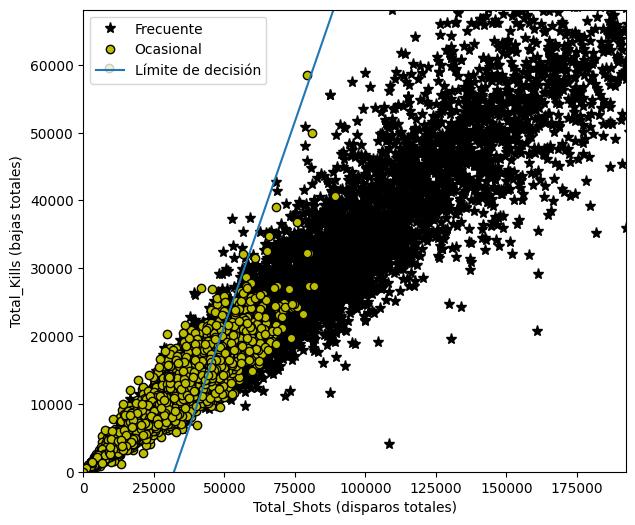

In [27]:
# Límites de los ejes en el percentil 90, solo para que el gráfico sea legible
xlim = (0, np.percentile(X_2d_train[:, 0], 90))
ylim = (0, np.percentile(X_2d_train[:, 1], 90))

plotDecisionBoundary(theta_2d, X_2d_train_b, y_2d_train, xlim=xlim, ylim=ylim)

Con los ejes ajustados se observa una separación bastante clara entre los jugadores frecuentes (que tienden a acumular más disparos y bajas totales) y los ocasionales, confirmando de forma visual lo que ya indicaba la precisión del modelo completo: el volumen de disparos y bajas es un buen indicador de qué tan frecuentemente juega una persona. El pequeño número de casos "mal clasificados" cerca de la recta corresponde a jugadores con hábitos atípicos (por ejemplo, mucha precisión con pocas partidas, o partidas largas pero con poca actividad de combate) que las otras variables del modelo completo (precisión, diversidad de armas, dificultad, fuego amigo) ayudan a corregir.

## 11. Conclusiones

- Se transformó el problema original de regresión (predecir horas jugadas) en un problema de **clasificación binaria**, definiendo como jugador "frecuente" a quien supera la mediana de horas jugadas del dataset, y "ocasional" a quien está por debajo.
- El preprocesamiento con **Pandas** permitió reducir 111 variables numéricas crudas a **10 variables agregadas** interpretables (precisión global, bajas por tipo de arma, diversidad de armas, fuego amigo y dificultad), evitando redundancia y facilitando el entrenamiento del modelo.
- El conjunto de datos se dividió en **80% entrenamiento / 20% prueba** de forma estratificada, y el conjunto de prueba no participó en ningún momento del ajuste de $\theta$ ni de la normalización.
- Se determinaron los parámetros $\theta$ de la regresión logística mediante **dos métodos**: descenso por el gradiente implementado manualmente, y el optimizador `TNC` de `scipy.optimize`. Ambos casos incluyen su respectivo gráfico de convergencia del costo.
- El modelo obtenido logra una precisión considerablemente mayor al 50% (nivel de un clasificador aleatorio dado que las clases están balanceadas), lo que indica que el estilo de juego (armas usadas, precisión, fuego amigo, dificultad) sí contiene información relevante para estimar qué tan frecuentemente juega una persona a Left 4 Dead 2.